In [ ]:
#Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

### Data Cleaning and Understanding

In [3]:
# Loading Data
df = pd.read_csv("student_performance_data.csv")
df.head()

,student_id,gender,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,internet_access,extra_classes,parent_education,sleep_hours,overall_score,grade
0,100000,Male,4.54,69.98,36.47,70.70,53.10,17.96,Yes,No,Master,8.09,52.3480,D
1,100001,Female,5.26,84.80,34.25,27.92,87.17,11.29,No,Yes,Bachelor,4.73,53.9485,D
2,100002,Male,8.69,73.76,72.29,70.92,99.61,76.10,No,Yes,PhD,8.73,82.0375,B
3,100003,Male,4.06,45.00,97.63,31.73,88.85,33.55,No,No,Bachelor,8.22,66.4110,C
4,100004,Male,8.83,51.13,65.19,78.28,54.23,88.99,No,No,Bachelor,8.59,65.6005,C


In [6]:
df.shape

(10000, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             10000 non-null  int64  
 1   gender                 10000 non-null  object 
 2   study_hours_per_day    10000 non-null  float64
 3   attendance_percentage  10000 non-null  float64
 4   assignment_score       10000 non-null  float64
 5   midterm_score          10000 non-null  float64
 6   final_exam_score       10000 non-null  float64
 7   participation_score    10000 non-null  float64
 8   internet_access        10000 non-null  object 
 9   extra_classes          10000 non-null  object 
 10  parent_education       10000 non-null  object 
 11  sleep_hours            10000 non-null  float64
 12  overall_score          10000 non-null  float64
 13  grade                  10000 non-null  object 
dtypes: float64(8), int64(1), object(5)
memory usage: 1.1+ M

In [8]:
df.describe()

,student_id,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,sleep_hours,overall_score
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,104999.50000,5.467825,70.493817,64.717809,62.322568,64.979987,55.103202,6.505165,63.826901
std,2886.89568,2.594134,17.295607,20.052779,21.710555,20.216141,25.955949,1.458246,10.230977
min,100000.00000,1.000000,40.000000,30.000000,25.000000,30.010000,10.000000,4.000000,33.263500
25%,102499.75000,3.220000,55.640000,47.320000,43.515000,47.400000,32.955000,5.220000,56.528125
50%,104999.50000,5.420000,70.780000,64.770000,62.050000,65.210000,55.055000,6.520000,63.780750
75%,107499.25000,7.740000,85.200000,81.760000,81.227500,82.500000,77.760000,7.792500,71.163125
max,109999.00000,10.000000,100.000000,99.990000,100.000000,100.000000,99.990000,9.000000,96.879500


In [9]:
# Checking for missing values
df.isnull().sum()

student_id               0
gender                   0
study_hours_per_day      0
attendance_percentage    0
assignment_score         0
midterm_score            0
final_exam_score         0
participation_score      0
internet_access          0
extra_classes            0
parent_education         0
sleep_hours              0
overall_score            0
grade                    0
dtype: int64

In [10]:
# Checking for duplicate values
df.duplicated().sum()

0

In [11]:
# Removing Irrelevant columns
df.drop("student_id", axis=1, inplace=True)

In [12]:
df.shape

(10000, 13)

In [14]:
#Viewing the value counts of gender column
df['gender'].value_counts()

Male      5013
Female    4987
Name: gender, dtype: int64

In [ ]:
#Viewing the value counts of grade
df['grade'].value_counts()

C    5073
B    2704
D    2008
A     154
F      61
Name: grade, dtype: int64

### Data Analysis

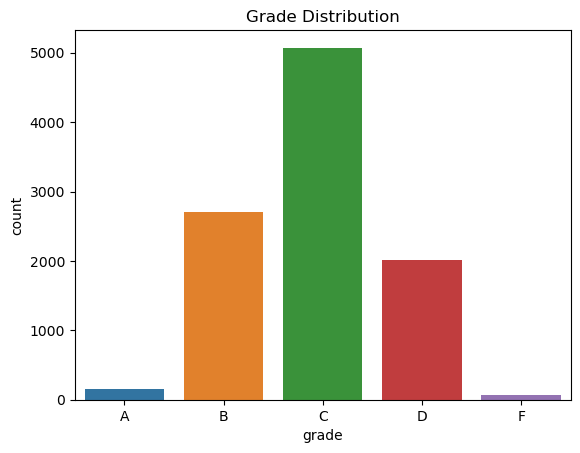

In [16]:
#How are students distributed by grade?
sns.countplot(x="grade", data=df, order=sorted(df["grade"].unique()))
plt.title("Grade Distribution")
plt.show()

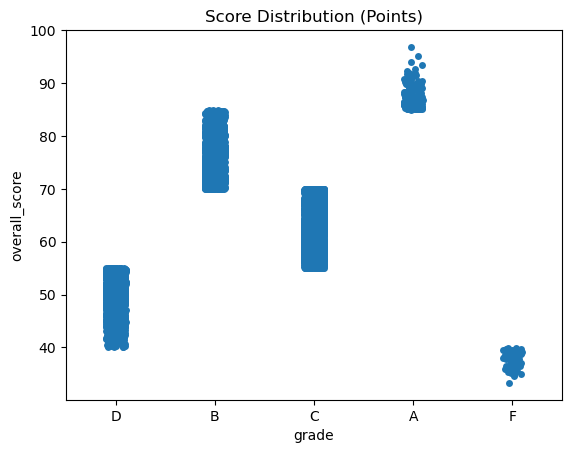

In [49]:
#Score Distribution
sns.stripplot(x="grade", y="overall_score", data=df)
plt.title("Score Distribution (Points)")
plt.show()

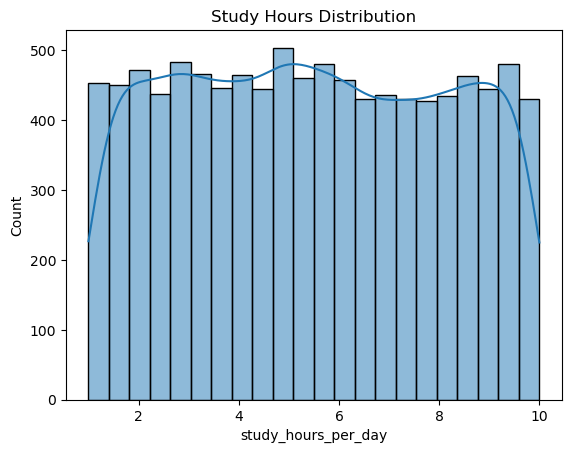

In [17]:
#Distribution of study hours
sns.histplot(df["study_hours_per_day"], kde=True)
plt.title("Study Hours Distribution")
plt.show()

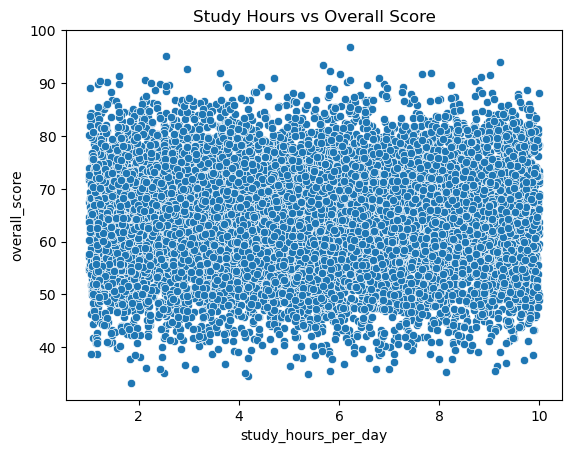

In [18]:
#Does study hours affect the score?
sns.scatterplot(x="study_hours_per_day", y="overall_score", data=df)
plt.title("Study Hours vs Overall Score")
plt.show()

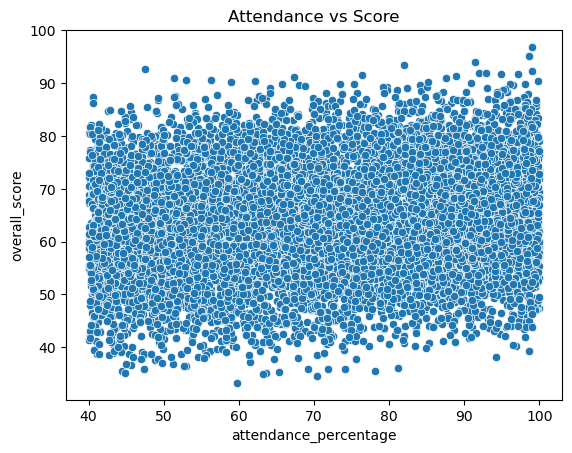

In [ ]:
#Does attendance affect the score?
sns.scatterplot(x="attendance_percentage", y="overall_score", data=df)
plt.title("Attendance vs Score")
plt.show()

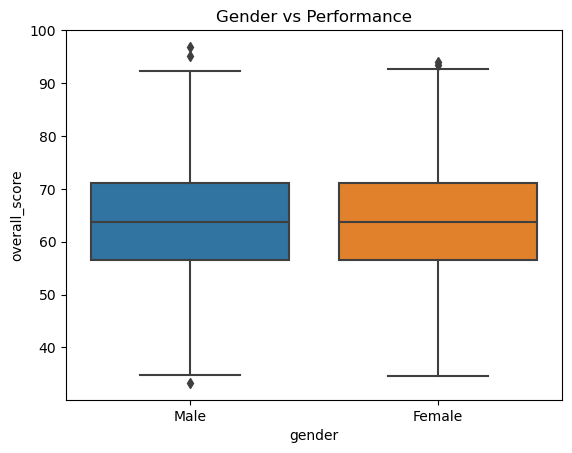

In [20]:
#Gender wise performance comparison
sns.boxplot(x="gender", y="overall_score", data=df)
plt.title("Gender vs Performance")
plt.show()

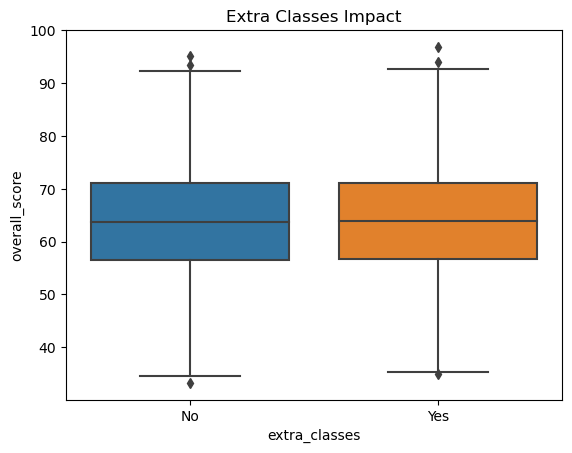

In [ ]:
#Does extra class help you get more score?
sns.boxplot(x="extra_classes", y="overall_score", data=df)
plt.title("Extra Classes Impact")
plt.show()

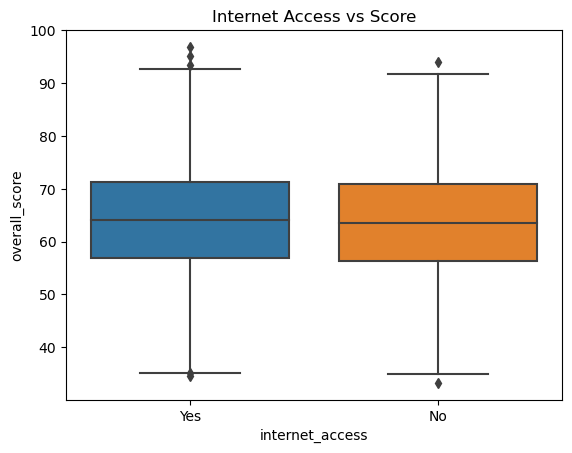

In [44]:
#Does internet access get you more score?
sns.boxplot(x="internet_access", y="overall_score", data=df)
plt.title("Internet Access vs Score")
plt.show()

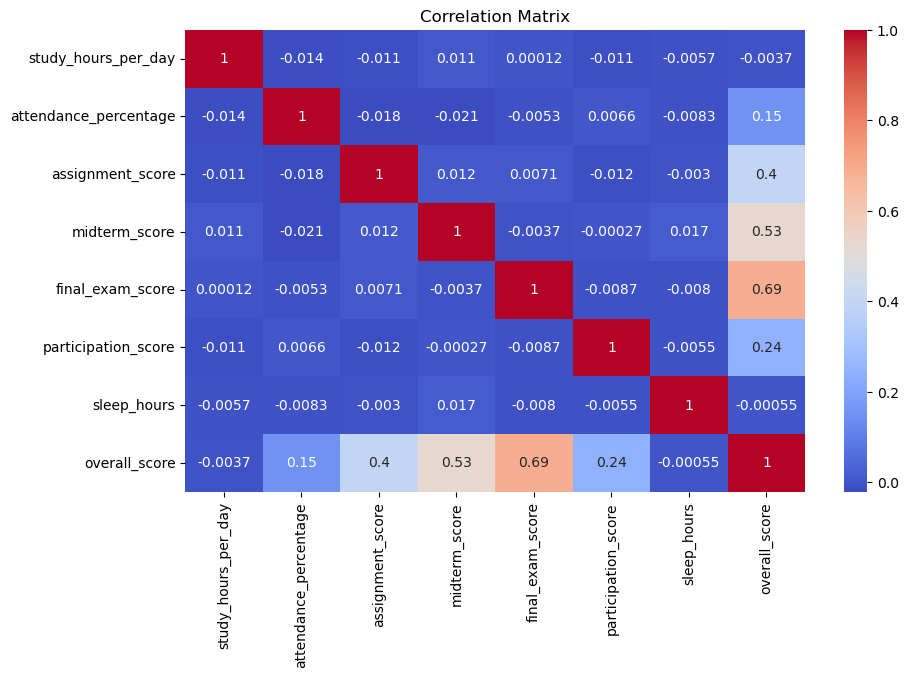

In [ ]:
#Correlation between numerical features
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

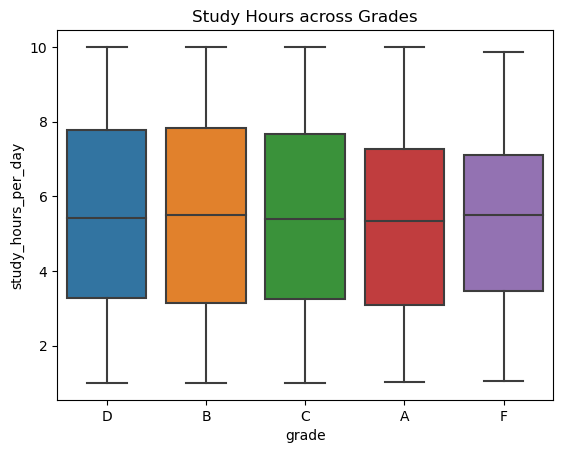

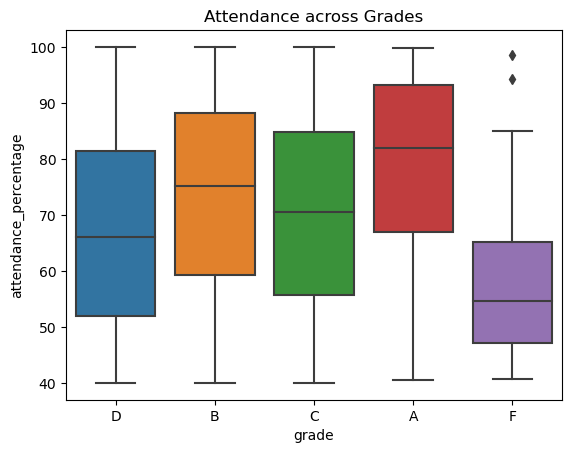

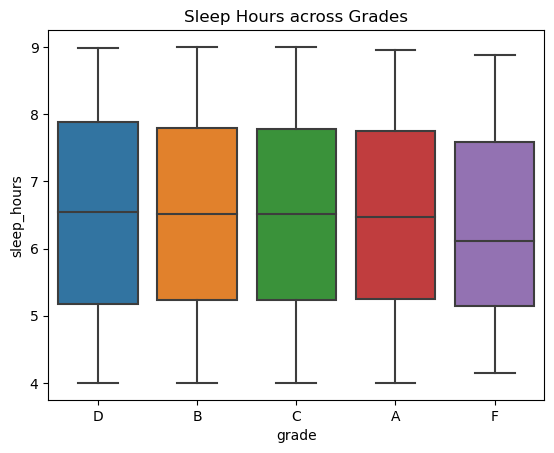

In [45]:
#How do features vary across grades?
sns.boxplot(x="grade", y="study_hours_per_day", data=df)
plt.title("Study Hours across Grades")
plt.show()

sns.boxplot(x="grade", y="attendance_percentage", data=df)
plt.title("Attendance across Grades")
plt.show()

sns.boxplot(x="grade", y="sleep_hours", data=df)
plt.title("Sleep Hours across Grades")
plt.show()

In [ ]:
#What combination leads to higher grades?
top_students = df[df["grade"] == "A"]

top_students.describe()

,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,sleep_hours,overall_score
count,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000
mean,5.293377,78.894221,87.392727,90.362338,91.784610,74.959481,6.472987,87.579114
std,2.552163,15.824369,10.571992,8.221690,6.327645,20.723868,1.432689,2.241929
min,1.030000,40.570000,53.280000,56.460000,74.000000,15.000000,4.000000,85.017500
25%,3.082500,66.937500,81.805000,85.902500,87.535000,64.087500,5.250000,85.930625
50%,5.340000,81.950000,90.540000,92.295000,93.285000,79.920000,6.475000,86.868750
75%,7.267500,93.140000,95.747500,96.817500,97.187500,91.105000,7.750000,88.748250
max,9.990000,99.830000,99.970000,99.910000,99.860000,99.890000,8.950000,96.879500


In [ ]:
#Which factor contributes most to score?
corr["overall_score"].sort_values(ascending=False)

overall_score            1.000000
final_exam_score         0.689326
midterm_score            0.528902
assignment_score         0.396961
participation_score      0.244067
attendance_percentage    0.148781
sleep_hours             -0.000551
study_hours_per_day     -0.003651
Name: overall_score, dtype: float64

In [57]:
#Average Performance by Gender
gender_scores = df.groupby("gender")[[
    "assignment_score", "midterm_score", 
    "final_exam_score", "overall_score"
]].mean()

gender_scores

,assignment_score,midterm_score,final_exam_score,overall_score
gender,,,,
Female,64.844885,62.163884,65.000545,63.830053
Male,64.591392,62.480429,64.959535,63.823766


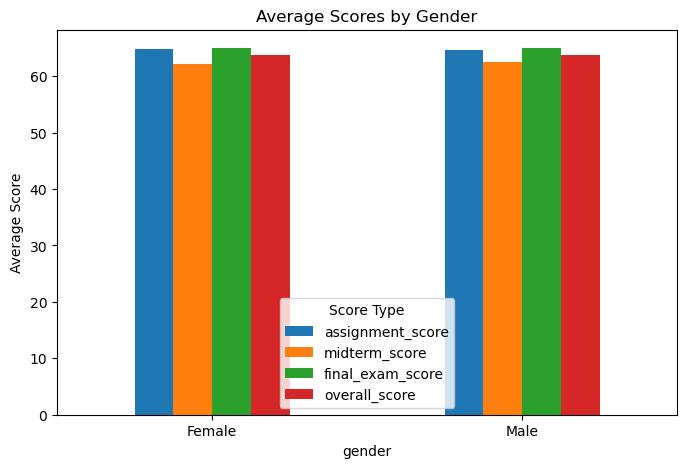

In [58]:
gender_scores.plot(kind="bar", figsize=(8,5))
plt.title("Average Scores by Gender")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.legend(title="Score Type")
plt.show()

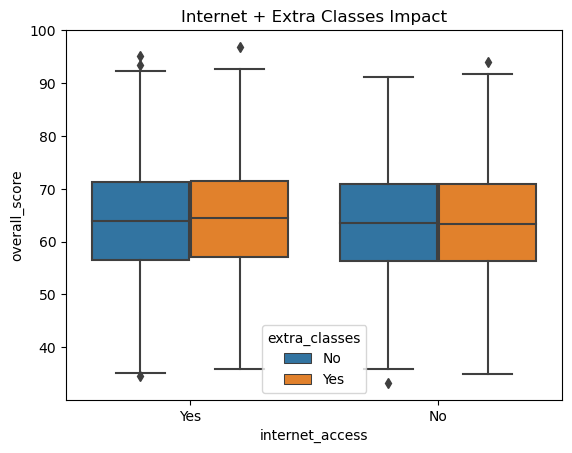

In [ ]:
#Combined effect of internet + extra classes
sns.boxplot(x="internet_access",
            y="overall_score",
            hue="extra_classes",
            data=df)
plt.title("Internet + Extra Classes Impact")
plt.show()

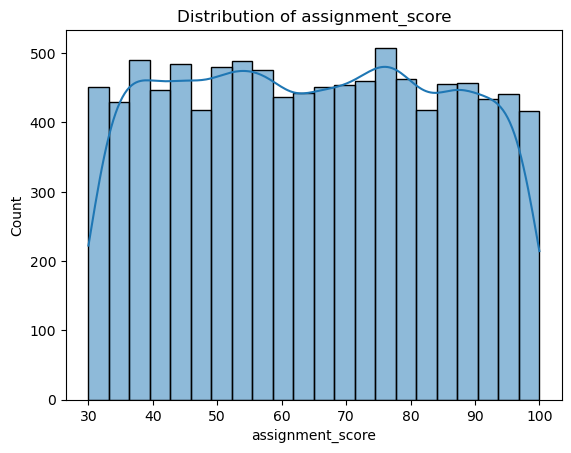

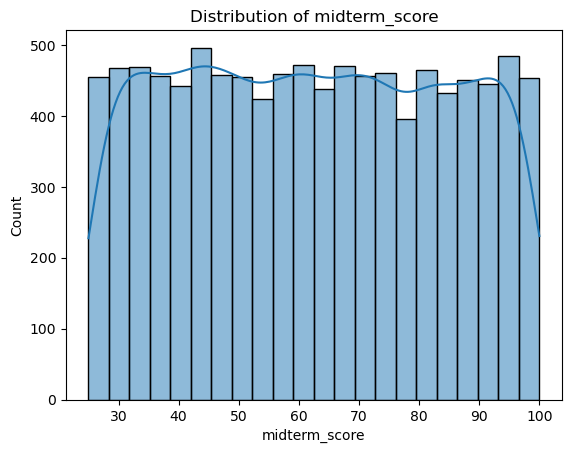

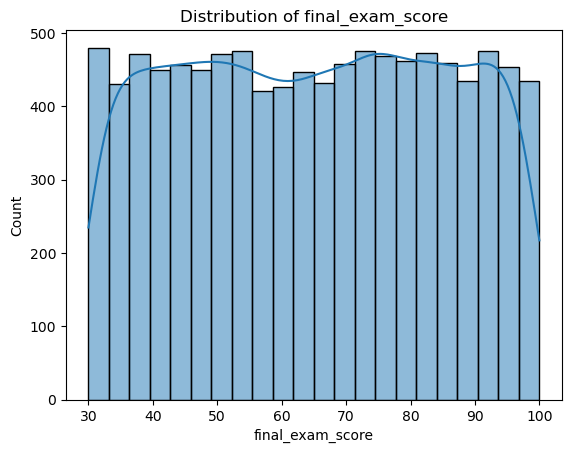

In [ ]:
#Are scores normally distributed?
for col in ["assignment_score", "midterm_score", "final_exam_score"]:
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

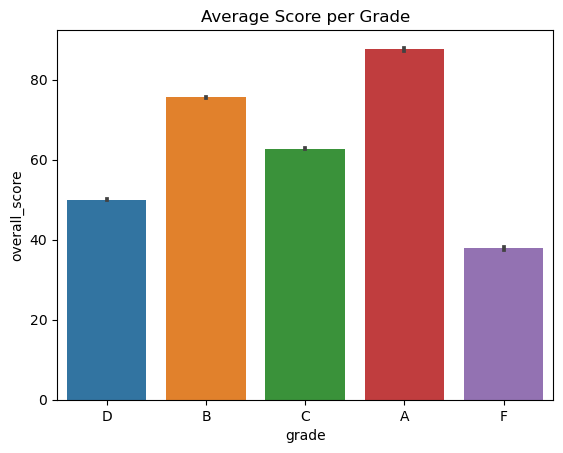

In [ ]:
#Average scores per grade
sns.barplot(x="grade", y="overall_score", data=df)
plt.title("Average Score per Grade")
plt.show()

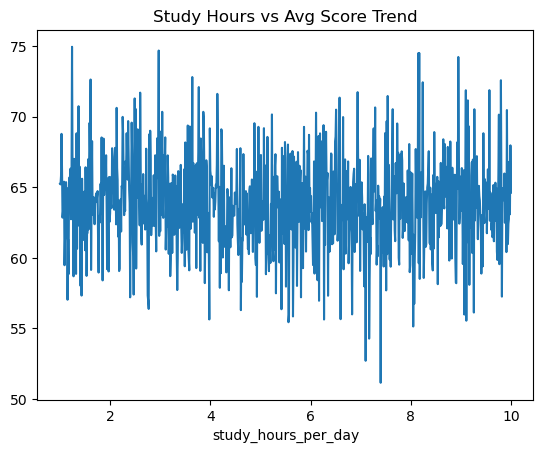

In [ ]:
#Study hours vs scores
df.groupby("study_hours_per_day")["overall_score"].mean().plot()
plt.title("Study Hours vs Avg Score Trend")
plt.show()

In [ ]:
#Average performance by internet access
df.groupby("internet_access")[
    ["overall_score", "final_exam_score"]
].mean()

,overall_score,final_exam_score
internet_access,,
No,63.525771,64.312936
Yes,64.120773,65.630958


In [ ]:
##Average performance by extra classes
df.groupby("extra_classes")["overall_score"].mean()

extra_classes
No     63.762164
Yes    63.889424
Name: overall_score, dtype: float64

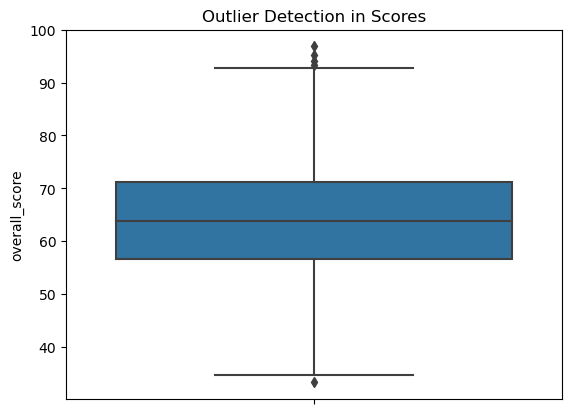

,gender,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,internet_access,extra_classes,parent_education,sleep_hours,overall_score,grade
3179,Male,1.85,59.80,30.78,27.32,34.53,22.12,No,No,Bachelor,7.30,33.2635,F
3598,Female,5.68,81.95,90.56,98.85,94.93,91.70,Yes,No,PhD,6.61,93.4150,A
5745,Male,6.22,98.96,96.15,99.64,97.79,86.17,Yes,Yes,Bachelor,4.64,96.8795,A
7374,Female,9.21,91.41,95.03,91.26,95.60,96.25,No,Yes,PhD,8.91,94.0470,A
8453,Male,2.55,98.61,88.66,98.96,98.81,82.90,Yes,No,High School,7.89,95.2065,A


In [ ]:
#Are there extreme performers?
sns.boxplot(y="overall_score", data=df)
plt.title("Outlier Detection in Scores")
plt.show()

# Identify outliers
Q1 = df["overall_score"].quantile(0.25)
Q3 = df["overall_score"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df["overall_score"] < Q1 - 1.5*IQR) |
              (df["overall_score"] > Q3 + 1.5*IQR)]

outliers

# Final Conclusion

## 🔍 Summary of Analysis
This exploratory data analysis examined the impact of academic behavior, lifestyle factors, and external resources on student performance. The analysis was conducted strictly using existing dataset features without feature engineering, ensuring unbiased insights.

---

## Key Findings

- **Study Hours:**  
  A strong positive relationship exists between daily study time and overall performance. Students who dedicate more time to studying tend to achieve higher scores.

- **Attendance:**  
  Attendance emerged as a critical factor, showing consistent influence across all performance metrics. Higher attendance is strongly associated with better academic outcomes.

- **Assessment Contributions:**  
  Among all evaluation components, the **final exam score** has the highest impact on overall performance, followed by midterm and assignment scores.

- **Sleep Patterns:**  
  Sleep shows a moderate relationship with performance. Students with balanced sleep durations tend to perform better than those with very low or excessive sleep.

- **Gender Comparison:**  
  Performance differences across gender are minimal, indicating that academic success is more behavior-driven than demographic-driven.

- **Internet Access & Extra Classes:**  
  Students with access to internet and those attending extra classes show slightly better performance, suggesting that additional resources provide a marginal advantage.

---

## Behavioral Insights

- High-performing students consistently demonstrate:
  - Higher study hours
  - Better attendance
  - Strong performance across all assessment components

- Lower-performing students often show:
  - Reduced study time
  - Lower attendance
  - Inconsistent academic scores

---

## Overall Conclusion
Student performance is primarily influenced by **consistent effort and engagement**, particularly through regular study and attendance. While external factors such as internet access and extra classes contribute to improvement, their impact is secondary compared to core academic behaviors.

---

## Final Remark
This analysis highlights that improving student outcomes should focus on:
- Encouraging consistent study habits  
- Maintaining high attendance  
- Supporting balanced lifestyle practices  

These factors collectively play a crucial role in achieving academic success.